# Land cover and Covariate Preparation

1) Fragmentation ECA
2) Land cover
3) Bare total
4) Small Woody Features
5) Grazing intensity


In [2]:
import rioxarray as rxr
from pathlib import Path

import numpy as np
from scipy import ndimage
from scipy.spatial.distance import cdist

import rasterio
from rasterio.transform import from_origin

import xarray as xr
from scipy.signal import fftconvolve
from rasterio.enums import Resampling
from rasterio import windows
from affine import Affine
import gc

import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

# Base path for all data
base_path = Path("/home/georg/data/LEON_P5_BII")

## Load LC layer

In [2]:
# Load LC layers for all countries and years #

clc_dir = base_path / "EO_data_prep/LC_with_plantation"

# Load with xarray 
dnk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_dnk_{year}.tif") for year in [2018, 2021, 2023]}
nld = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_nld_{year}.tif") for year in [2018, 2021, 2023]}
# uk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_uk_{year}.tif") for year in [2018, 2023]}


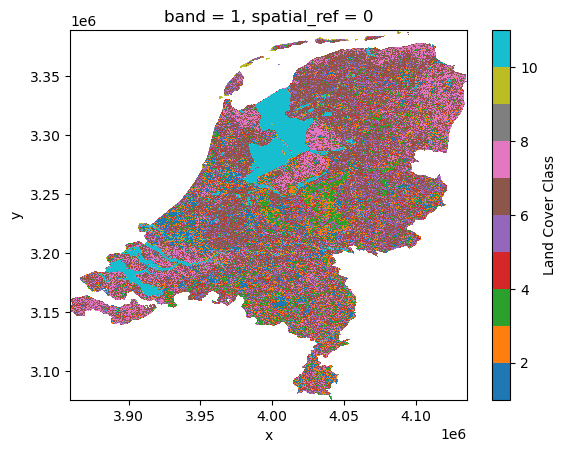

In [3]:
# Plot LC for overview
nld[2023].where((nld[2023] >= 1) & (nld[2023] <= 11)).coarsen(x=10, y=10, boundary="trim").mean().plot(
    cmap='tab10',
    vmin=1,
    vmax=11,
    cbar_kwargs={'label': 'Land Cover Class'}
)

# Fragmentation ECA(PC)

In [ ]:
# ECA - Equivalent Connected Area
# Based on probability of connectivity


##___Config___##
NATURAL_CLASSES = [2, 5]  # Adjust to your natural habitat classes
CELL_SIZE_M = 1000
PIXEL_SIZE_M = 10
DISPERSAL_DISTANCE = 500  # meters
cell_pixels = CELL_SIZE_M // PIXEL_SIZE_M

def calc_eca(lc_data, natural_classes, cell_pixels, dispersal_dist, pixel_size):
    """Calculate ECA in hectares"""
    # Binary natural habitat mask
    natural_mask = np.isin(lc_data, natural_classes).astype(np.uint8)
    
    # Grid dimensions
    rows = natural_mask.shape[0] // cell_pixels
    cols = natural_mask.shape[1] // cell_pixels
    eca_grid = np.zeros((rows, cols))
    
    for i in range(rows):
        for j in range(cols):
            cell = natural_mask[i*cell_pixels:(i+1)*cell_pixels,
                               j*cell_pixels:(j+1)*cell_pixels]
            
            # Label patches
            labeled, num = ndimage.label(cell)
            
            if num > 0:
                patch_sizes = np.bincount(labeled.ravel())[1:]
                patch_areas = patch_sizes * (pixel_size ** 2)
                total_area = patch_areas.sum()
                
                # Get centroids
                centroids = np.array([
                    ndimage.center_of_mass(labeled == pid) 
                    for pid in range(1, num + 1)
                ]) * pixel_size
                
                # Distances between patches
                distances = cdist(centroids, centroids) if num > 1 else np.array([[0]])
                
                # ECA calculation
                pc_sum = 0
                for p1 in range(num):
                    for p2 in range(num):
                        prob = 1.0 if p1 == p2 else np.exp(-distances[p1, p2] / dispersal_dist)
                        pc_sum += patch_areas[p1] * patch_areas[p2] * prob
                
                pc = pc_sum / (total_area ** 2)
                eca_grid[i, j] = np.sqrt(pc) * total_area / 10000  # to hectares
    
    return eca_grid

# Calculate ECA for all countries and years
eca_results = {}

for country_name, country_data in [('uk', uk), ('dnk', dnk), ('nld', nld)]:  # 
    eca_results[country_name] = {}
    
    for year in [2018, 2021, 2023]:
        if year not in country_data:
            print(f"Skipping {country_name.upper()} {year} (no data)")
            continue       
          
        print(f"Processing {country_name.upper()} {year}...")
        lc_array = country_data[year].values[0]  # Get numpy array from xarray
        
        eca_grid = calc_eca(lc_array, NATURAL_CLASSES, cell_pixels, 
                           DISPERSAL_DISTANCE, PIXEL_SIZE_M)
        
        eca_results[country_name][year] = eca_grid
        
        print(f"  Mean ECA: {eca_grid[eca_grid > 0].mean():.2f} ha")



In [ ]:
#__Transform & Save__#


output_dir = base_path / "EO_data_prep/ECA"
output_dir.mkdir(exist_ok=True, parents=True)

for country in ['uk','dnk', 'nld']: # 
    for year in [2018, 2021, 2023]:  # 
        if year not in eca_results[country]:
            continue
        # Get original transform and scale it
        original = eval(country)[year]  # Get xarray
        transform = original.rio.transform()
        scaled_transform = rasterio.Affine(
            transform.a * cell_pixels, transform.b, transform.c,
            transform.d, transform.e * cell_pixels, transform.f
        )
        
        # Save
        output_path = output_dir / f"eca_{country}_{year}.tif"
        with rasterio.open(output_path, 'w', driver='GTiff',
                          height=eca_results[country][year].shape[0],
                          width=eca_results[country][year].shape[1],
                          count=1, dtype='float32',
                          crs=original.rio.crs,
                          transform=scaled_transform,
                          compress='lzw') as dst:
            dst.write(eca_results[country][year], 1)
        
        print(f"Saved: {output_path}")

# Tree height diversity
Structural diversity of plantations. Low CV = intense all planted at the same time monoculture, high CV = minimal trees not planted at the same time potentially no monoculture

In [3]:
import xarray as xr
import rioxarray
import numpy as np
from pathlib import Path

tree_height_dir = base_path / "EO_data_prep" / "Tree_Height"

files = {
    "dnk": tree_height_dir / "canopy_height_dnk_clip.tif",
    "nld": tree_height_dir / "canopy_height_nld_clip.tif",
}

out_dir = base_path / "EO_data_prep" / "Structural_Diversity"
out_dir.mkdir(parents=True, exist_ok=True)

def compute_cv_coarsened(filepath, factor=20, min_height=2.0):
    """
    Compute coefficient of variation of canopy height
    aggregated to coarser resolution using non-overlapping blocks.
    
    Parameters
    ----------
    filepath : Path to canopy height GeoTIFF (5m resolution)
    factor : int, coarsen factor (20 → 100m blocks at 5m input)
    min_height : float, mask pixels below this as nodata
        (removes ground/water from the stats)
    """
    da = xr.open_dataarray(
        filepath, engine="rasterio", chunks={"y": 2000, "x": 2000}
    ).squeeze("band", drop=True)

    # mask out nodata and below-threshold pixels
    da = da.where(da > min_height)

    # trim edges so dimensions are divisible by factor
    y_trim = da.sizes["y"] - (da.sizes["y"] % factor)
    x_trim = da.sizes["x"] - (da.sizes["x"] % factor)
    da = da.isel(y=slice(0, y_trim), x=slice(0, x_trim))

    # coarsen: compute mean and std per block
    blocks = da.coarsen(y=factor, x=factor)
    mean = blocks.mean()
    std = blocks.std()

    # CV = std / mean
    cv = std / mean
    cv = cv.where(mean > min_height)

    # preserve CRS
    cv.rio.write_crs(da.rio.crs, inplace=True)
    cv.rio.write_transform(inplace=True)

    return cv

for country, fpath in files.items():
    print(f"Processing {country}...")
    cv = compute_cv_coarsened(fpath, factor=20, min_height=0.0)
    out_path = out_dir / f"cv_height_100m_{country}.tif"
    cv.rio.to_raster(out_path, tiled=True)
    print(f"  → {out_path}  shape={cv.shape}")

Processing dnk...


/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/home/georg/python/miniconda3/envs/bii/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


  → /home/georg/data/LEON_P5_BII/EO_data_prep/Structural_Diversity/cv_height_100m_dnk.tif  shape=(3536, 4509)
Processing nld...


/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/home/georg/python/miniconda3/envs/bii/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


  → /home/georg/data/LEON_P5_BII/EO_data_prep/Structural_Diversity/cv_height_100m_nld.tif  shape=(3131, 2762)


# Land cover
In the following cells we will define LC classes used for the LU intensity
1) Plantation
2) Secondary Vegetation
3) Pasture

Ideally it is executed in the same order or once happy with a dataset reuse from previous step. The final LC layer used for LU intensity classifcation is the LC_Pasture

## Plantation
### Plantation = Woody - Natural Forest

In [5]:
import numpy as np
from pathlib import Path
import rioxarray as rxr
from rasterio.enums import Resampling
import rasterio
from rasterio.transform import from_bounds
import gc

# ============== CHANGE THIS ==============
COUNTRY = 'dnk'  # Options: 'dnk', 'nld', 'uk'
# =========================================

WOODY_CLASSES = [2, 3, 4]
NATURAL_THRESHOLD = 1

# Paths
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/CLCplus").expanduser()
nat_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Natural_forest_2020").expanduser()
output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
output_dir.mkdir(exist_ok=True, parents=True)

YEARS = {
    'dnk': [2018, 2021, 2023],
    'nld': [2018, 2021, 2023],
}

print(f"\n{'='*60}")
print(f"PROCESSING: {COUNTRY.upper()}")
print(f"{'='*60}\n")

# Load natural forest once
nat_path = nat_dir / f"natural_forest_{COUNTRY}.tif"
print(f"Loading natural forest...")
nat_forest = rxr.open_rasterio(nat_path)

for year in YEARS[COUNTRY]:
    print(f"\n--- Year {year} ---")
    
    lc_path = lc_dir / f"clcplus_{COUNTRY}_{year}.tif"
    lc = rxr.open_rasterio(lc_path)
    
    # Resample
    print("  Resampling...")
    nat_resampled = nat_forest.rio.reproject_match(lc, resampling=Resampling.bilinear)
    
    # Classify IN-PLACE (no copy)
    print("  Classifying...")
    lc_arr = lc.values[0]
    nat_arr = nat_resampled.values[0]
    
    is_woody = np.isin(lc_arr, WOODY_CLASSES)
    is_plantation = is_woody & (nat_arr < NATURAL_THRESHOLD)
    is_natural = is_woody & (nat_arr >= NATURAL_THRESHOLD)
    
    print(f"    Natural: {is_natural.sum():,} | Plantation: {is_plantation.sum():,}")
    
    # Modify IN-PLACE
    lc_arr[is_natural] = 2
    lc_arr[is_plantation] = 3
    
    # Save using rasterio directly (more efficient)
    print("  Saving...")
    output_path = output_dir / f"lc_forest_{NATURAL_THRESHOLD}_{COUNTRY}_{year}.tif"
    
    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=lc_arr.shape[0],
        width=lc_arr.shape[1],
        count=1,
        dtype=lc_arr.dtype,
        crs=lc.rio.crs,
        transform=lc.rio.transform(),
        compress='LZW'
    ) as dst:
        dst.write(lc_arr, 1)
    
    print(f"  ✓ {output_path.name}")
    
    # Aggressive cleanup
    del lc, nat_resampled, lc_arr, nat_arr, is_woody, is_plantation, is_natural
    gc.collect()

del nat_forest
gc.collect()

print(f"\n✅ {COUNTRY.upper()} COMPLETE!")


PROCESSING: DNK

Loading natural forest...

--- Year 2018 ---
  Resampling...
  Classifying...
    Natural: 44,730,681 | Plantation: 37,874,759
  Saving...
  ✓ lc_forest_1_dnk_2018.tif

--- Year 2021 ---
  Resampling...
  Classifying...
    Natural: 43,987,264 | Plantation: 37,027,412
  Saving...
  ✓ lc_forest_1_dnk_2021.tif

--- Year 2023 ---
  Resampling...
  Classifying...
    Natural: 43,020,126 | Plantation: 35,179,920
  Saving...
  ✓ lc_forest_1_dnk_2023.tif

✅ DNK COMPLETE!


In [ ]:
# from pathlib import Path

# output_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Forest_classification")
# output_dir.mkdir(exist_ok=True, parents=True)

# # DNK
# for year in [2018, 2021, 2023]:
#     classification = classify_forest(dnk[year].values[0], dnk_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
#     template = dnk[year].copy()
#     template.values[0] = classification
#     template.rio.to_raster(output_dir / f"forest_dnk_{year}.tif", compress='LZW')
#     print(f"✓ forest_dnk_{year}.tif")

# # NLD
# for year in [2018, 2021, 2023]:
#     classification = classify_forest(nld[year].values[0], nld_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
#     template = nld[year].copy()
#     template.values[0] = classification
#     template.rio.to_raster(output_dir / f"forest_nld_{year}.tif", compress='LZW')
#     print(f"✓ forest_nld_{year}.tif")

# # UK
# for year in [2018, 2023]:
#     classification = classify_forest(uk[year].values[0], uk_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
#     template = uk[year].copy()
#     template.values[0] = classification
#     template.rio.to_raster(output_dir / f"forest_uk_{year}.tif", compress='LZW')
#     print(f"✓ forest_uk_{year}.tif")

# print("\nAll saved!")

## Secondary Vegetation Categorisation

In [6]:
import rioxarray as rxr
from pathlib import Path

clc_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/LC_with_plantation")
td_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Tree_Density")

NATURAL_THRESHOLD = 1

# Xarray
# Land cover + Plantation
lc_dnk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_{NATURAL_THRESHOLD}_dnk_{year}.tif") for year in [2018, 2021, 2023]}
lc_nld = {year: rxr.open_rasterio(clc_dir / f"lc_forest_{NATURAL_THRESHOLD}_nld_{year}.tif") for year in [2018, 2021, 2023]}

# Tree Density (note: files have _merged suffix)
td_dnk = {year: rxr.open_rasterio(td_dir / f"tree_cover_density_dnk_{year}_merged.tif") for year in [2018, 2021, 2023]}
td_nld = {year: rxr.open_rasterio(td_dir / f"tree_cover_density_nld_{year}_merged.tif") for year in [2018, 2021, 2023]}

In [7]:
import os
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
td_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Tree_Density").expanduser()

for f in sorted(lc_dir.glob(f"*dnk*")):
    print(f"{f.name}: {os.path.getsize(f) / 1e6:.0f} MB")
for f in sorted(td_dir.glob(f"*dnk*")):
    print(f"{f.name}: {os.path.getsize(f) / 1e6:.0f} MB")

lc_forest_10_dnk_2018.tif: 59 MB
lc_forest_10_dnk_2021.tif: 61 MB
lc_forest_10_dnk_2023.tif: 61 MB
lc_forest_10_dnk_2023.tif.aux.xml: 0 MB
lc_forest_1_dnk_2018.tif: 59 MB
lc_forest_1_dnk_2021.tif: 62 MB
lc_forest_1_dnk_2023.tif: 61 MB
lc_forest_20_dnk_2018.tif: 59 MB
lc_forest_20_dnk_2021.tif: 61 MB
lc_forest_20_dnk_2023.tif: 61 MB
lc_forest_30_dnk_2018.tif: 58 MB
lc_forest_30_dnk_2021.tif: 61 MB
lc_forest_30_dnk_2023.tif: 61 MB
tree_cover_density_dnk_2018_merged.tif: 353 MB
tree_cover_density_dnk_2019_merged.tif: 345 MB
tree_cover_density_dnk_2020_merged.tif: 343 MB
tree_cover_density_dnk_2021_merged.tif: 350 MB
tree_cover_density_dnk_2022_merged.tif: 338 MB
tree_cover_density_dnk_2023_merged.tif: 341 MB


In [8]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from rasterio.windows import Window
from pathlib import Path
import numpy as np
import tempfile
import os
import gc

lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
td_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Tree_Density").expanduser()
output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_secondary_veg").expanduser()
output_dir.mkdir(parents=True, exist_ok=True)

TD_YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
LC_YEAR_MAP = {2018: 2018, 2019: 2018, 2020: 2018,
               2021: 2021, 2022: 2021, 2023: 2023}
COUNTRIES = ['dnk', 'nld']
TILE_SIZE = 2048  # rows per tile — tune if still tight on memory


def reproject_to_tempfile(src_path, ref_profile):
    """Reproject src to match ref profile, writing to a temp file on disk."""
    tmp_path = src_path.parent / f"_tmp_reproj_{src_path.stem}.tif"
    
    with rasterio.open(src_path) as src:
        dst_profile = ref_profile.copy()
        dst_profile.update(dtype=src.dtypes[0], count=1, compress='LZW')
        
        with rasterio.open(tmp_path, 'w', **dst_profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_profile['transform'],
                dst_crs=ref_profile['crs'],
                resampling=Resampling.bilinear,
            )
    return tmp_path


for country in COUNTRIES:
    print(f"\n{country.upper()}")
    
    prev_lc_year = None
    lc_profile = None
    lc_path = None
    
    for year in TD_YEARS:
        lc_year = LC_YEAR_MAP[year]
        print(f"  {year} (LC from {lc_year})...", end=" ")
        
        # Get LC reference profile (only when LC year changes)
        if lc_year != prev_lc_year:
            lc_path = lc_dir / f"lc_forest_{NATURAL_THRESHOLD}_{country}_{lc_year}.tif"
            with rasterio.open(lc_path) as lc_src:
                lc_profile = lc_src.profile.copy()
            prev_lc_year = lc_year
        
        td_path = td_dir / f"tree_cover_density_{country}_{year}_merged.tif"
        
        # Step 1: reproject TD to disk, matching LC grid
        print("reprojecting...", end=" ")
        td_reproj_path = reproject_to_tempfile(td_path, lc_profile)
        
        # Step 2: process in tiles
        print("reclassifying...", end=" ")
        output_path = output_dir / f"lc_sv_{country}_{year}.tif"
        out_profile = lc_profile.copy()
        out_profile.update(compress='LZW')
        
        with rasterio.open(lc_path) as lc_src, \
             rasterio.open(td_reproj_path) as td_src, \
             rasterio.open(output_path, 'w', **out_profile) as dst:
            
            h, w = lc_src.height, lc_src.width
            
            for row_off in range(0, h, TILE_SIZE):
                win_h = min(TILE_SIZE, h - row_off)
                window = Window(0, row_off, w, win_h)
                
                lc_arr = lc_src.read(1, window=window)
                td_arr = td_src.read(1, window=window)
                output = lc_arr.copy()
                
                is_natural = (lc_arr == 2)
                output[is_natural & (td_arr > 90) & (td_arr <= 100)] = 21
                output[is_natural & (td_arr >= 70) & (td_arr <= 90)] = 22
                output[is_natural & (td_arr < 70)] = 23
                output[lc_arr == 5] = 24
                
                dst.write(output, 1, window=window)
                
                del lc_arr, td_arr, output
        
        # Clean up temp file
        os.remove(td_reproj_path)
        gc.collect()
        print("✓")

print("\n✅ Done!")


DNK
  2018 (LC from 2018)... reprojecting... reclassifying... ✓
  2019 (LC from 2018)... reprojecting... reclassifying... ✓
  2020 (LC from 2018)... reprojecting... reclassifying... ✓
  2021 (LC from 2021)... reprojecting... reclassifying... ✓
  2022 (LC from 2021)... reprojecting... reclassifying... ✓
  2023 (LC from 2023)... reprojecting... reclassifying... ✓

NLD
  2018 (LC from 2018)... reprojecting... reclassifying... ✓
  2019 (LC from 2018)... reprojecting... reclassifying... ✓
  2020 (LC from 2018)... reprojecting... reclassifying... ✓
  2021 (LC from 2021)... reprojecting... reclassifying... ✓
  2022 (LC from 2021)... reprojecting... reclassifying... ✓
  2023 (LC from 2023)... reprojecting... reclassifying... ✓

✅ Done!


In [ ]:
# import rioxarray as rxr
# import numpy as np
# import rasterio
# from pathlib import Path
# import gc

# # Setup - expand ~ to full path
# lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
# td_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Tree_Density").expanduser()
# output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_secondary_veg").expanduser()
# output_dir.mkdir(parents=True, exist_ok=True)

# YEARS = [2018, 2021, 2023]
# COUNTRIES = ['dnk', 'nld']

# # Process each country
# for country in COUNTRIES:
#     print(f"\n{country.upper()}")
    
#     for year in YEARS:
#         print(f"  {year}...")
        
#         # Load data
#         lc = rxr.open_rasterio(lc_dir / f"lc_forest_{NATURAL_THRESHOLD}_{country}_{year}.tif")
#         td = rxr.open_rasterio(td_dir / f"tree_cover_density_{country}_{year}_merged.tif")
        
#         # Resample tree density to match land cover
#         td = td.rio.reproject_match(lc, resampling=rasterio.enums.Resampling.bilinear)
        
#         # Get arrays
#         lc_arr = lc.values.squeeze()
#         td_arr = td.values.squeeze()
#         output = lc_arr.copy()
        
#         # Reclassify Natural Forest (class 2) by tree density
#         is_natural = (lc_arr == 2)
#         output[is_natural & (td_arr > 90) & (td_arr <= 100)] = 21                          # SV Mature
#         output[is_natural & (td_arr >= 70) & (td_arr <= 90)] = 22       # SV Intermediate
#         output[is_natural & (td_arr < 70)] = 23                          # SV Young
#         output[lc_arr == 5] = 24                                         # SV Indeterminate
        
#         # Save
#         output_path = output_dir / f"lc_sv_{country}_{year}.tif"
#         with rasterio.open(
#             output_path, 'w',
#             driver='GTiff',
#             height=output.shape[0],
#             width=output.shape[1],
#             count=1,
#             dtype=output.dtype,
#             crs=lc.rio.crs,
#             transform=lc.rio.transform(),
#             compress='LZW'
#         ) as dst:
#             dst.write(output, 1)
        
#         # Cleanup
#         del lc, td, lc_arr, td_arr, output
#         gc.collect()

# print("\n✅ Done!")

## Urban / Pasture / Natural Grassland


In [11]:
# Classify Urban Grassland and Pasture
#
# Steps per tile:
#   1. Start with land cover (LC) values as baseline
#   2. Calculate sealed surface density in 1km radius around each pixel
#   3. Grassland pixels with sealed density > 5% → Urban Minimal (31)
#   4. Grassland pixels with sealed density ≤ 5% → Pasture (41)
#   5. Pasture pixels with 0 mowing events → SV Indeterminate (24)

import rioxarray as rxr
import numpy as np
from scipy.ndimage import uniform_filter
from pathlib import Path
import gc

# ============== CHANGE THIS ==============
COUNTRY = 'nld'  # 'dnk' or 'nld'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

# =========================================

# Constants
SEALED_VALUE = 1
GRASSLAND_CLASSES = [1]
URBAN_THRESHOLD_PCT = 5
WINDOW_RADIUS_M = 1000
PIXEL_SIZE = 10
TILE_SIZE = 5000
OVERLAP = 200
DOWNSAMPLE = 5

# Output classes
URBAN_MINIMAL = 31
PASTURE = 41
SV_INDETERMINATE = 24

# Paths
base = Path("~/data/LEON_P5_BII/EO_data_prep").expanduser()
out_dir = base / "LC_urban_pasture"
out_dir.mkdir(exist_ok=True, parents=True)

# Window size for sealed density
win_px = 2 * int(WINDOW_RADIUS_M / PIXEL_SIZE) + 1
win_small = win_px // DOWNSAMPLE

print(f"\nProcessing {COUNTRY.upper()} | window={win_px}px | tile={TILE_SIZE}px\n")

for year in YEARS:
    print(f"--- {year} ---")

    # Load rasters (select band=0 explicitly to guarantee 2D)
    lc = rxr.open_rasterio(base / f"LC_with_secondary_veg/lc_sv_{COUNTRY}_{year}.tif", masked=True, chunks={'x': TILE_SIZE, 'y': TILE_SIZE}).isel(band=0)
    grass = rxr.open_rasterio(base / f"Grassland/grassland_{COUNTRY}_{year}.tif", masked=True, chunks={'x': TILE_SIZE, 'y': TILE_SIZE}).isel(band=0)
    mow = rxr.open_rasterio(base / f"grassland_mowing_events/grassland_mowing_events_{COUNTRY}_{year}_clip.tif", masked=True, chunks={'x': TILE_SIZE, 'y': TILE_SIZE}).isel(band=0)

    # Crop to common extent
    nr = min(lc.shape[0], grass.shape[0], mow.shape[0])
    nc = min(lc.shape[1], grass.shape[1], mow.shape[1])
    lc = lc.isel(y=slice(0, nr), x=slice(0, nc))
    grass = grass.isel(y=slice(0, nr), x=slice(0, nc))
    mow = mow.isel(y=slice(0, nr), x=slice(0, nc))
    print(f"  Shape: ({nr}, {nc})")

    rows, cols = nr, nc
    output = np.zeros((rows, cols), dtype=np.uint8)

    for ty in range(int(np.ceil(rows / TILE_SIZE))):
        for tx in range(int(np.ceil(cols / TILE_SIZE))):
            # Tile bounds with overlap (for density edge effects)
            ys, ye = max(0, ty * TILE_SIZE - OVERLAP), min(rows, (ty + 1) * TILE_SIZE + OVERLAP)
            xs, xe = max(0, tx * TILE_SIZE - OVERLAP), min(cols, (tx + 1) * TILE_SIZE + OVERLAP)
            # Core bounds (what we write to output)
            ycs, yce = ty * TILE_SIZE, min(rows, (ty + 1) * TILE_SIZE)
            xcs, xce = tx * TILE_SIZE, min(cols, (tx + 1) * TILE_SIZE)

            # Load tiles into memory
            lc_t = lc.isel(y=slice(ys, ye), x=slice(xs, xe)).values
            gr_t = grass.isel(y=slice(ys, ye), x=slice(xs, xe)).values
            mw_t = mow.isel(y=slice(ys, ye), x=slice(xs, xe)).values

            # Step 1: start with LC values
            tile_out = lc_t.copy()

            # Step 2: sealed surface density (downsampled for speed)
            sealed = (lc_t == SEALED_VALUE).astype(np.float32)
            density = uniform_filter(sealed[::DOWNSAMPLE, ::DOWNSAMPLE], size=win_small, mode='constant')
            density = np.repeat(np.repeat(density, DOWNSAMPLE, axis=0), DOWNSAMPLE, axis=1)
            density = density[:sealed.shape[0], :sealed.shape[1]] * 100

            is_grass = np.isin(gr_t, GRASSLAND_CLASSES)
            is_urban = density > URBAN_THRESHOLD_PCT

            # Step 3: grassland in urban areas → Urban Minimal (31)
            tile_out[is_grass & is_urban] = URBAN_MINIMAL

            # Step 4: grassland outside urban areas → Pasture (41)
            tile_out[is_grass & ~is_urban] = PASTURE

            # Step 5: pasture with 0 mowing events → SV Indeterminate (24)
            tile_out[(tile_out == PASTURE) & (mw_t == 0)] = SV_INDETERMINATE

            # Write core region to output
            yo, xo = ycs - ys, xcs - xs
            output[ycs:yce, xcs:xce] = tile_out[yo:yo + (yce - ycs), xo:xo + (xce - xcs)]

            del lc_t, gr_t, mw_t, sealed, density, tile_out
            gc.collect()

    # Summary & save
    print(f"  Urban(31): {(output == URBAN_MINIMAL).sum():,}  "
          f"Pasture(41): {(output == PASTURE).sum():,}  "
          f"SV_Indet(24): {(output == SV_INDETERMINATE).sum():,}")

    out_file = out_dir / f"lc_urban{URBAN_THRESHOLD_PCT}_pasture_natgrass_{COUNTRY}_{year}.tif"
    lc.copy(data=output).rio.to_raster(out_file, compress='LZW')
    print(f"  Saved: {out_file}\n")

    del lc, grass, mow, output
    gc.collect()

print("Done!")


Processing NLD | window=201px | tile=5000px

--- 2018 ---
  Shape: (31312, 27628)
  Urban(31): 58,693,448  Pasture(41): 54,028,984  SV_Indet(24): 6,078,286
  Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/LC_urban_pasture/lc_urban5_pasture_natgrass_nld_2018.tif

--- 2019 ---
  Shape: (31312, 27628)
  Urban(31): 58,010,909  Pasture(41): 51,288,184  SV_Indet(24): 8,365,699
  Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/LC_urban_pasture/lc_urban5_pasture_natgrass_nld_2019.tif

--- 2020 ---
  Shape: (31312, 27628)
  Urban(31): 57,385,699  Pasture(41): 50,168,887  SV_Indet(24): 8,811,552
  Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/LC_urban_pasture/lc_urban5_pasture_natgrass_nld_2020.tif

--- 2021 ---
  Shape: (31312, 27628)
  Urban(31): 58,943,760  Pasture(41): 45,781,252  SV_Indet(24): 10,316,344
  Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/LC_urban_pasture/lc_urban5_pasture_natgrass_nld_2021.tif

--- 2022 ---
  Shape: (31312, 27628)
  Urban(31): 56,314,963  Pasture(41)

# Bare total
Get total bare by adding bare before and after of the same year

In [6]:
##___Configuration___##
folder_in = "Bare"
folder_out = "Bare_Total"
countries = ['dnk', 'nld']
years = [2018, 2020, 2021, 2022, 2023]
MAX_VALUE = 370
# Paths #
bare_dir =  base_path / "EO_data_prep" / folder_in
output_dir = base_path / "EO_data_prep" / folder_out
output_dir.mkdir(exist_ok=True)

for country in countries:
    for year in years:
        print(f"Processing {country.upper()} {year}...")
        
        before_path = bare_dir / f"bare_before_{country}_{year}_clip.tif"
        after_path = bare_dir / f"bare_after_{country}_{year}_clip.tif"
        output_path = output_dir / f"bare_total_{country}_{year}.tif"
        
        with rasterio.open(before_path) as before_src, \
             rasterio.open(after_path) as after_src:
            
            profile = before_src.profile.copy()
            profile.update(compress='LZW')
            
            # Process in chunks
            with rasterio.open(output_path, 'w', **profile) as dst:
                for ji, window in before_src.block_windows(1):
                    before_data = before_src.read(1, window=window).astype(float)
                    after_data = after_src.read(1, window=window).astype(float)
                    
                    # Filter > 370 BEFORE adding
                    before_data[before_data > MAX_VALUE] = np.nan
                    after_data[after_data > MAX_VALUE] = np.nan
                    
                    # Add (np.nan propagates correctly)
                    total_data = before_data + after_data
                    
                    # Replace np.nan values with 90
                    total_data[np.isnan(total_data)] = 90
                    
                    dst.write(total_data.astype(profile['dtype']), 1, window=window)
        
        print(f"  ✓ Saved: {output_path.name}")
print("\nDone!")

Processing DNK 2018...
  ✓ Saved: bare_total_dnk_2018.tif
Processing DNK 2020...
  ✓ Saved: bare_total_dnk_2020.tif
Processing DNK 2021...
  ✓ Saved: bare_total_dnk_2021.tif
Processing DNK 2022...
  ✓ Saved: bare_total_dnk_2022.tif
Processing DNK 2023...
  ✓ Saved: bare_total_dnk_2023.tif
Processing NLD 2018...
  ✓ Saved: bare_total_nld_2018.tif
Processing NLD 2020...
  ✓ Saved: bare_total_nld_2020.tif
Processing NLD 2021...
  ✓ Saved: bare_total_nld_2021.tif
Processing NLD 2022...
  ✓ Saved: bare_total_nld_2022.tif
Processing NLD 2023...
  ✓ Saved: bare_total_nld_2023.tif

Done!


# Density Small Woody Features
A Gaussian‑weighted density map is used to account for distance‑decay effects, reflecting the stronger ecological influence of nearby habitat. This is considered more ecologically meaningful than a uniform (non‑distance‑weighted) density. The method can be changed to a uniform circular kernel if distance weighting is not desired. Current radius set to 500m, can be adjusted as well e.g. 1000m.

In [ ]:
# ============== SETTINGS ==============
COUNTRY = 'nld'  # Options: 'dnk', 'nld', 'uk'
RADIUS_M = 500  # Radius in meters
KERNEL_TYPE = 'gaussian'  # 'circular' or 'gaussian'
# ======================================

SWF_CLASS = [1]
RESOLUTION = 5  # SWF resolution in meters
TILE_SIZE = 10000  # Tile size for processing

# Paths
swf_dir = base_path / "EO_data_prep" / "Small_Woody_Features"
lc_dir = base_path / "EO_data_prep" / "CLCplus"
output_dir = base_path / "EO_data_prep" / "Small_Woody_Features"

YEARS = {
    'dnk': [2018],  #2021, 
    'nld': [2018, 2021],
}

# Create kernel
radius_px = int(RADIUS_M / RESOLUTION)
kernel_size = 2 * radius_px + 1
overlap = kernel_size

y, x = np.ogrid[-radius_px:radius_px+1, -radius_px:radius_px+1]

if KERNEL_TYPE == 'gaussian':
    sigma_px = radius_px / 3.0
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma_px**2))
    circular_mask = (x**2 + y**2 <= radius_px**2)
    kernel = kernel * circular_mask
    print(f"Gaussian kernel: radius={RADIUS_M}m, sigma={sigma_px:.1f}px")
else:
    kernel = (x**2 + y**2 <= radius_px**2).astype(float)
    print(f"Circular kernel: radius={RADIUS_M}m")

kernel = kernel / kernel.sum()

def calculate_density(block):
    density = fftconvolve(block.astype(float), kernel, mode='same')
    return np.clip(density * 10000, 0, 10000).astype(np.uint16)

# Process each year
for year in YEARS[COUNTRY]:
    print(f"\n{'='*50}")
    print(f"Processing {COUNTRY} {year}")
    print(f"{'='*50}")
    
    # Load reference data
    lc_file = lc_dir / f"clcplus_{COUNTRY}_{year}.tif"
    with rasterio.open(lc_file) as src:
        lc_profile = src.profile.copy()
        lc_transform = src.transform
        lc_height = src.height
        lc_width = src.width
        lc_crs = src.crs
    
    # Load SWF data
    swf_file = swf_dir / f"small_woody_features_{COUNTRY}_{year}.tif"
    swf = rxr.open_rasterio(swf_file)
    if 'band' in swf.dims:
        swf = swf.sel(band=1, drop=True)
    
    ny, nx = swf.shape
    print(f"Processing {ny}x{nx} pixels in {int(np.ceil(ny/TILE_SIZE) * np.ceil(nx/TILE_SIZE))} tiles")
    
    # Setup output
    output_path = output_dir / f"swf_density_{RADIUS_M}m_{KERNEL_TYPE}_{COUNTRY}_{year}.tif"
    lc_profile.update({
        'dtype': 'uint16',
        'count': 1,
        'compress': 'lzw',
        'tiled': True,
        'blockxsize': 256,
        'blockysize': 256,
        'nodata': 65535
    })
    
    # Process tiles
    with rasterio.open(output_path, 'w', **lc_profile) as dst:
        n_tiles_y = int(np.ceil(ny / TILE_SIZE))
        n_tiles_x = int(np.ceil(nx / TILE_SIZE))
        
        for i in range(n_tiles_y):
            for j in range(n_tiles_x):
                print(f"  Tile {i*n_tiles_x + j + 1}/{n_tiles_y*n_tiles_x} ({i},{j})...", end=' ', flush=True)
                
                # Define tile bounds
                core_y_start, core_y_end = i * TILE_SIZE, min((i + 1) * TILE_SIZE, ny)
                core_x_start, core_x_end = j * TILE_SIZE, min((j + 1) * TILE_SIZE, nx)
                
                ext_y_start, ext_y_end = max(0, core_y_start - overlap), min(ny, core_y_end + overlap)
                ext_x_start, ext_x_end = max(0, core_x_start - overlap), min(nx, core_x_end + overlap)
                
                # Extract and process tile
                swf_tile = swf.isel(y=slice(ext_y_start, ext_y_end), x=slice(ext_x_start, ext_x_end)).values
                swf_mask = np.isin(swf_tile, SWF_CLASS).astype(int)
                density_tile = calculate_density(swf_mask)
                
                # Extract core region
                core_y = slice(core_y_start - ext_y_start, core_y_start - ext_y_start + (core_y_end - core_y_start))
                core_x = slice(core_x_start - ext_x_start, core_x_start - ext_x_start + (core_x_end - core_x_start))
                density_core = density_tile[core_y, core_x]
                
                # Resample to 10m
                out_y_start, out_y_end = int(core_y_start / 2), int(np.ceil(core_y_end / 2))
                out_x_start, out_x_end = int(core_x_start / 2), int(np.ceil(core_x_end / 2))
                
                dst_array = np.full((out_y_end - out_y_start, out_x_end - out_x_start), 65535, dtype=np.uint16)
                
                rasterio.warp.reproject(
                    source=density_core,
                    destination=dst_array,
                    src_transform=swf.rio.transform() * Affine.translation(core_x_start, core_y_start),
                    src_crs=swf.rio.crs,
                    dst_transform=lc_transform * Affine.translation(out_x_start, out_y_start),
                    dst_crs=lc_crs,
                    resampling=Resampling.average,
                    src_nodata=65535,
                    dst_nodata=65535,
                )
                
                dst.write(dst_array, 1, window=windows.Window(out_x_start, out_y_start, out_x_end - out_x_start, out_y_end - out_y_start))
                print("✓", flush=True)
                
                del swf_tile, swf_mask, density_tile, density_core, dst_array
                gc.collect()
    
    print(f"✓ Saved: {output_path}")
    del swf
    gc.collect()

print("\n" + "="*50)
print("Done! 🎉")
print("="*50)

# Grazing intensity
Following (Piipponen et al. 2022) using MODIS NPP

## Streamlined grazing intensity calc

In [ ]:
from pathlib import Path
from grazing_intensity import compute_rsd

base_path = Path("~/data/LEON_P5_BII").expanduser()
lc_dir = base_path / "EO_data_prep/CLCplus"

# ── LC year mapping ──
LC_YEARS = [2018, 2021, 2023]

def nearest_lc_year(year):
    candidates = [y for y in LC_YEARS if y <= year]
    return max(candidates) if candidates else min(LC_YEARS)

# ── Setup & Run ──
for country in ["nld", "dnk"]:
    for year in range(2018, 2024):
        lc_year = nearest_lc_year(year)
        print(f"  {country} {year} → LC {lc_year}")
        compute_rsd(
            npp_path=base_path / f"EO_data_prep/Modis_NPP/NPP_{country}_{year}_clip.tif",
            temp_path=base_path / f"EO_data_prep/Temp_avg/wc2.1_2.5m_tavg_{country}_mean_annual.tif",
            lc_path=lc_dir / f"clcplus_{country}_{lc_year}.tif",
            livestock_paths={
                "cattle": base_path / f"EO_data_prep/Lifestock_GPW/gpw_cattle.headcount.faostat_rf_m_1km_s_{country}_{year}_clip.tif",
                "sheep":  base_path / f"EO_data_prep/Lifestock_GPW/gpw_sheep.headcount.faostat_rf_m_1km_s_{country}_{year}_clip.tif",
                "goat":   base_path / f"EO_data_prep/Lifestock_GPW/gpw_goat.headcount.faostat_rf_m_1km_s_{country}_{year}_clip.tif",
                "horse":  base_path / f"EO_data_prep/Lifestock_GPW/gpw_horse.headcount.faostat_rf_m_1km_s_{country}_{year}_clip.tif",
            },
            out_path=base_path / f"EO_data_prep/Grazing_intensity/RSD_{country}_{year}.tif",
            country=country,
        )

  nld 2018 → LC 2018
✅  RSD_nld_2018.tif  —  min=0.000  mean=0.938  median=0.158  max=14677.474
  nld 2019 → LC 2018
✅  RSD_nld_2019.tif  —  min=0.000  mean=1.004  median=0.163  max=19093.172
  nld 2020 → LC 2018
✅  RSD_nld_2020.tif  —  min=0.000  mean=0.944  median=0.162  max=15141.438
  nld 2021 → LC 2021
✅  RSD_nld_2021.tif  —  min=0.000  mean=0.966  median=0.161  max=17129.857
  nld 2022 → LC 2021
✅  RSD_nld_2022.tif  —  min=0.000  mean=0.922  median=0.150  max=17255.053
  nld 2023 → LC 2023
✅  RSD_nld_2023.tif  —  min=0.000  mean=0.945  median=0.155  max=20563.385
  dnk 2018 → LC 2018
✅  RSD_dnk_2018.tif  —  min=0.000  mean=0.256  median=0.051  max=702.551
  dnk 2019 → LC 2018
✅  RSD_dnk_2019.tif  —  min=0.000  mean=0.259  median=0.050  max=560.271
  dnk 2020 → LC 2018
✅  RSD_dnk_2020.tif  —  min=0.000  mean=0.253  median=0.050  max=568.381
  dnk 2021 → LC 2021
✅  RSD_dnk_2021.tif  —  min=0.000  mean=0.259  median=0.052  max=633.254
  dnk 2022 → LC 2021
✅  RSD_dnk_2022.tif  —  min

#### Check RSD
How much average RSD within Pasture areas

In [ ]:
# Inputs
pasture_path = base_path / "EO_data_prep/LC_urban_pasture/lc_urban5_pasture_dnk_2023.tif"

PASTURE_VALUE = 41  # pasture class
TARGET_SHAPE = RSD.shape     # (rows, cols)
TARGET_PROFILE = profile     # from NPP (EPSG:3035)

# Reproject pasture raster to RSD grid #
with rasterio.open(pasture_path) as src:
    pasture_reproj = np.full(TARGET_SHAPE, np.nan, dtype="float32")
    reproject(
        source=rasterio.band(src, 1),
        destination=pasture_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=TARGET_PROFILE["transform"],
        dst_crs=TARGET_PROFILE["crs"],
        src_nodata=src.nodata,
        dst_nodata=np.nan,
        resampling=Resampling.nearest
    )

# Build pasture mask on RSD grid
pasture_mask = pasture_reproj == PASTURE_VALUE

print("Pasture pixels (RSD grid):", np.sum(pasture_mask))
print("Pasture fraction of grid:",
      np.sum(pasture_mask) / pasture_mask.size)

# Apply mask and compute stats
RSD_pasture = np.where(pasture_mask, RSD, np.nan)

print("\nRSD over pasture only:")
print("  Min :", np.nanmin(RSD_pasture))
print("  Mean:", np.nanmean(RSD_pasture))
print("  Max :", np.nanmax(RSD_pasture))


In [ ]:
plt.hist(RSD_pasture[np.isfinite(RSD_pasture)], bins=50, log=True); 
plt.xlabel("RSD"); plt.ylabel("Pixel count"); plt.title("Histogram of pasture RSD"); plt.show()

In [ ]:

print(dict(zip([5,10,25,50,75,90,95,99], np.nanpercentile(RSD_pasture, [5,10,25,50,75,90,95,99]))))


Interpretation (Piipponen et al. 2022)

RSD value Interpretation: < 0.20 Low grazing pressure; 0.20 – 0.65 Sustainable grazing; > 0.65 Overstocked